### GJ-9827d JWST NIRISS SOSS Spectrum



In [1]:
from POSEIDON.core import wl_grid_constant_R
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_J, R_E, M_E
from scipy.constants import parsec as pc

#***** Model wavelength grid *****#

wl_min = 0.58      # Minimum wavelength (um)
wl_max = 5.30      # Maximum wavelength (um)
R = 20000          # Spectral resolution of grid      

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define stellar properties *****#

R_s = 0.58*R_Sun      # Stellar radius (m)
T_s = 4236.0          # Stellar effective temperature (K)
err_T_s = 12          # Value in ExoMast
Met_s = -0.29         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.719       # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
                   stellar_grid = 'phoenix', wl = wl)
# star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
#                   stellar_grid = 'phoenix', interp_backend = 'pymsg', wl = wl)

#***** Define planet properties *****#

planet_name = 'GJ-9827d'  # Planet name used for plots, output files etc.

R_p = 1.89*R_E     # Planetary radius (m)
M_p = 3.02*M_E      # Planet mass
T_eq = 599.68       # Equilibrium temperature (K)
d = 29.6610*pc       # Distance to system (m)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq, d = d)

/home/eraul/New_Research/POSEIDON/POSEIDON/absorption.py:1466: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def store_Rayleigh_eta_LBL(wl_model, chemical_species):


Load data

In [2]:
from POSEIDON.core import load_data
from POSEIDON.visuals import plot_data
import numpy as np

#***** Specify data location and instruments *****#

data_dir = './data/' + planet_name

datasets = [#planet_name + '_NIRISS_SOSS_Ord2.dat',
            planet_name + '_NIRISS_SOSS_Ord1.dat'#,
            # planet_name + '_NIRSpec_G395H_NRS1.dat',
            # planet_name + '_NIRSpec_G395H_NRS2.dat',
            ]

instruments = [#'JWST_NIRISS_SOSS_Ord2',
               'JWST_NIRISS_SOSS_Ord1'#,
            #    'JWST_NIRSPec_G395H_NRS1', 'JWST_NIRSPec_G395H_NRS2',
              ]

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)

Old data

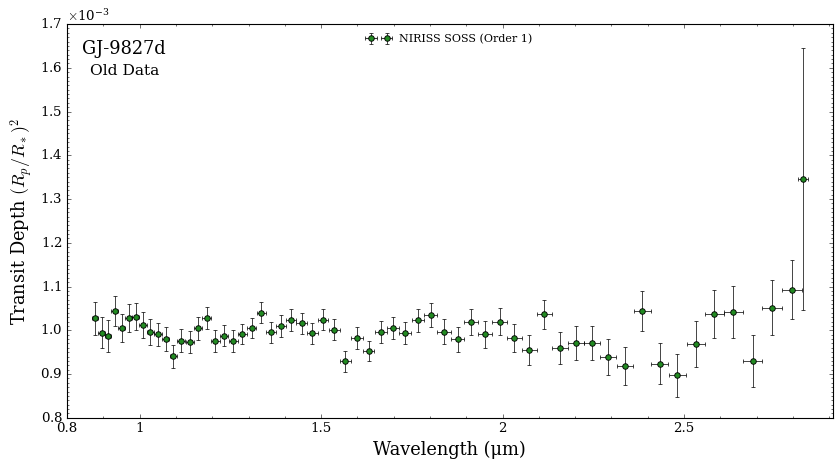

In [4]:
fig_data = plot_data(data, planet_name, plt_label = 'Old Data',
                     data_labels = [#'NIRISS SOSS (Order 2)', 
                                    'NIRISS SOSS (Order 1)'#,
                                    #'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)'
                                    ],
                     data_colour_list = [#'navy', 
                                         'forestgreen',
                                         #'orange', 'crimson'
                                         ],
                     data_marker_list = ['o'],
                     data_marker_size_list = [5],
                     legend_location = 'upper center',
                     wl_axis = 'linear', figure_shape = 'wide',
                    #  show_data_bin_width = False
                    )

New data

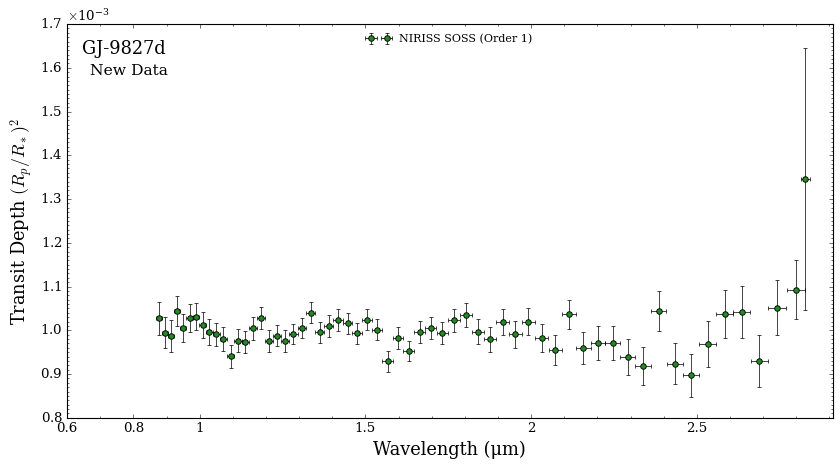

In [5]:
# fig_data = plot_data(data, planet_name, plt_label = 'New Data',
#                      data_labels = ['NIRISS SOSS (Order 2)', 'NIRISS SOSS (Order 1)',
#                                     'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)'],
#                      data_colour_list = ['navy', 'forestgreen',
#                                          'orange', 'crimson'],
#                      data_marker_list = ['o', 'o', 'D', 'D'],
#                      data_marker_size_list = [5, 5, 4.5, 4.5],
#                      wl_min = 0.6,
#                      legend_location = 'upper center',
#                      wl_axis = 'linear', figure_shape = 'wide',
#                     #  show_data_bin_width = False
#                      )

fig_data = plot_data(data, planet_name, plt_label = 'New Data',
                     data_labels = ['NIRISS SOSS (Order 1)',
                                    ],
                     data_colour_list = ['forestgreen',
                                         ],
                     data_marker_list = ['o'],
                     data_marker_size_list = [5],
                     wl_min = 0.6,
                     legend_location = 'upper center',
                     wl_axis = 'linear', figure_shape = 'wide',
                    #  show_data_bin_width = False
                     )

Comparison

In [6]:
#***** Specify data location and instruments *****#

data_dir = './data/' + planet_name

datasets = [
            planet_name + '_NIRISS_SOSS_Ord1.dat',

            planet_name + '_WFC3_G141.dat',
            ]

instruments = ['JWST_NIRISS_SOSS_Ord1',
               'WFC3_G141'
              ]

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)

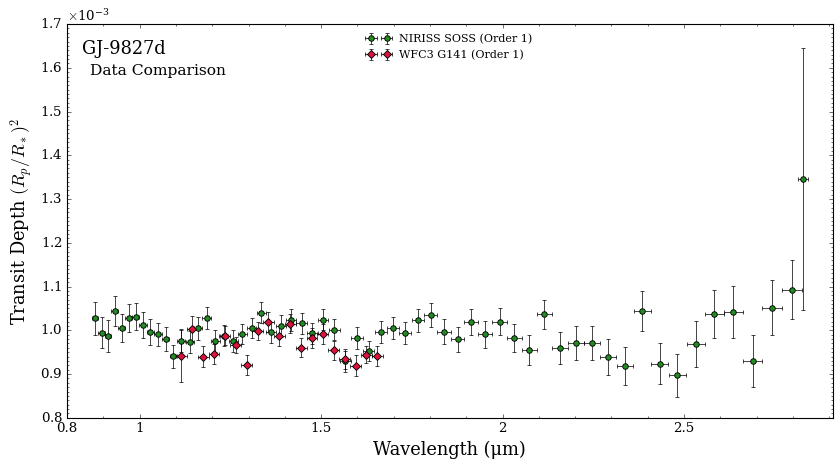

In [20]:
fig_data = plot_data(data, planet_name, plt_label = 'Data Comparison',
                     data_labels = ['NIRISS SOSS (Order 1)',
                                    'WFC3 G141 (Order 1)'],
                     data_colour_list = ['forestgreen',
                                         'crimson'],
                     data_marker_list = ['o', 'D'],
                     data_marker_size_list = [5, 4.5],
                     #wl_min = 0.8, y_min = .8e-3,
                     legend_location = 'upper center',
                     wl_axis = 'linear', figure_shape = 'wide',
                    #  show_data_bin_width = False
                     )

### Retrieval results plots

In [22]:
from POSEIDON.constants import R_Sun, R_J, R_E, M_E
from POSEIDON.core import create_star, create_planet, load_data, define_model, \
                          wl_grid_constant_R
from POSEIDON.utility import read_retrieved_spectrum, read_retrieved_PT, \
                             plot_collection
from POSEIDON.corner import generate_cornerplot
from POSEIDON.utility import read_retrieved_spectrum, read_retrieved_PT, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved, plot_PT_retrieved, plot_histograms

import numpy as np
from spectres import spectres

from scipy.constants import parsec as pc

data_included = 'NIRISS'

#***** Model wavelength grid *****#

wl_min = 0.58      # Minimum wavelength (um)           2.8
wl_max = 5.30      # Maximum wavelength (um)           5.3
R = 20000          # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define stellar properties *****#

R_s = 0.58*R_Sun      # Stellar radius (m)
T_s = 4236.0          # Stellar effective temperature (K)
err_T_s = 12          # Value in ExoMast
Met_s = -0.29         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.719       # Stellar log surface gravity (log10(cm/s^2) by convention)
err_log_g_s = 0.013

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, wl = wl)
# star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
#                   log_g_error = err_log_g_s, # stellar_grid = 'cbk04')
#                   stellar_grid = 'phoenix', interp_backend = 'pymsg',
#                   wl = wl)

#***** Define planet properties *****#

planet_name = 'GJ-9827d'   # Planet name used for plots, output files etc.

R_p = 1.89*R_E     # Planetary radius (m)
M_p = 3.02*M_E      # Planet mass
T_eq = 599.68       # Equilibrium temperature (K)
d = 29.6610*pc       # Distance to system (m)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq, d = d)

#***** Specify data location and instruments *****#

data_dir = './data/' + planet_name

datasets = []
instruments = []

if ('NIRISS' in data_included):

    # datasets.append(planet_name + '_NIRISS_SOSS_Ord2.dat')
    datasets.append(planet_name + '_NIRISS_SOSS_Ord1.dat')
    # instruments.append('JWST_NIRISS_SOSS_Ord2')
    instruments.append('JWST_NIRISS_SOSS_Ord1')

if ('G395H' in data_included):

    datasets.append(planet_name + '_NIRSpec_G395H_NRS1.dat')
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2.dat')
  #  datasets.append(planet_name + '_NIRSpec_G395H.dat')
    instruments.append('JWST_NIRSpec_G395H_NRS1')
    instruments.append('JWST_NIRSpec_G395H_NRS2')
  #  instruments.append('JWST_NIRSpec_G395H')

data = load_data(data_dir, datasets, instruments, wl)
               #  offset_datasets = [planet_name + '_NIRSpec_G395H.dat'])

Read retrieval results

In [31]:
#***** Define model *****#

model_name = 'NH3_SO2_SOSS_' + data_included# + '_offset'

bulk_species = ['H2', 'He']     # H2 + He comprises the bulk atmosphere
param_species = ['H2O', 'CH4', 'CO2', 'CO', 'NH3', 'SO2', 'H2S']

# Create the model object
model = define_model(model_name, bulk_species, param_species, 
                     PT_profile = 'isotherm', cloud_model = 'MacMad17',
                     cloud_type = 'deck_haze', cloud_dim = 1,
                     radius_unit = 'R_E', surface = False,
                     stellar_contam = None,
                     offsets_applied = 'single_dataset',
                     )

# Create composite spectra objects for plotting
spectra_median = []
spectra_low2 = []
spectra_low1 = []
spectra_high1 = []
spectra_high2 = []

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

# Add retrieved spectra to composite objects
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1) 
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2) 
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1) 
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

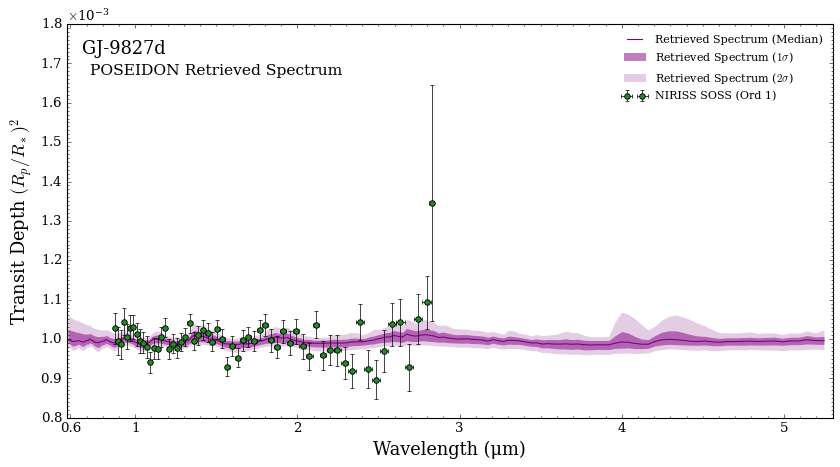

In [32]:
if (data_included == 'NIRISS'):
    data_colour_list = [#'navy', 
                        'forestgreen']
    data_labels = [#'NIRISS SOSS (Ord 2)', 
                   'NIRISS SOSS (Ord 1)']
    data_marker_list = [#'o',
                         'o']
    data_marker_size_list = [#5,
                              5]
elif (data_included == 'G395H'):
    data_colour_list = ['crimson', 'orange']
    data_labels = ['NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)']
    data_marker_list = ['o', 'o']
    data_marker_size_list = [5, 5]
else:
    data_colour_list = ['navy', 'forestgreen', 
                        'crimson', 'orange']
    data_labels = ['NIRISS SOSS (Ord 2)', 'NIRISS SOSS (Ord 1)',
                   'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)']
    data_marker_list = ['o', 'o', 'o', 'o']
    data_marker_size_list = [5, 5, 5, 5]
  #  data_colour_list = ['navy', 'forestgreen', 'crimson']
  #  data_labels = ['NIRISS SOSS (Ord 2)', 'NIRISS SOSS (Ord 1)', 'NIRSPec G395H']
  #  data_marker_list = ['o', 'o', 'o']
  #  data_marker_size_list = [5, 5, 5]

fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100, show_ymodel = False,
                                  plt_label = 'POSEIDON Retrieved Spectrum',
                                  data_colour_list = data_colour_list,
                                  data_labels = data_labels,
                                  data_marker_list = data_marker_list,
                                  data_marker_size_list = data_marker_size_list,
                                  figure_shape = 'wide', wl_axis = 'linear',
                                  #wl_min = wl_min, wl_max = wl_max,
                                  #show_data_bin_width = False,
                                  )

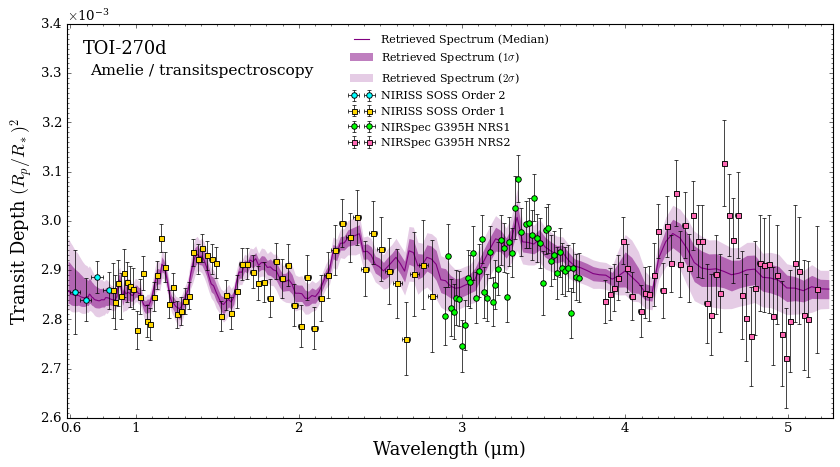

In [10]:
fig_spec_1 = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                    spectra_high1, spectra_high2, planet_name,
                                    data, R_to_bin = 100, show_ymodel = False,
                                    plt_label = r'Amelie / transitspectroscopy',
                                    colour_list = ['purple'],
                                    data_colour_list = ['cyan', 'gold', 'lime', 'hotpink'],
                                    data_labels = ['NIRISS SOSS Order 2',
                                                   'NIRISS SOSS Order 1',
                                                   'NIRSpec G395H NRS1',
                                                   'NIRSpec G395H NRS2'],
                                    data_marker_list = ['o', 's', 'o', 's'],
                                    data_marker_size_list = [5, 4.5, 5, 4.5],
                                    figure_shape = 'wide', wl_axis = 'linear',
                                    legend_location = 'upper center',
                                    wl_min = 0.58, wl_max = 5.27,
                                    # y_min = 4.38e-3, y_max = 5.86e-3,
                                    #show_data_bin_width = False,
                                    #show_data_cap = False,
                                    #data_alpha = 0.6,
                                    save_fig = False,
                                    #data_edge_width = 1.2,
                                    # text_annotations = ['Cloud', 'Li?', 'CrH?', 'H$_2$O', 
                                    #                     'H$_2$O', 'Cloud', 'H$_2$O', 'Cloud', 
                                    #                     'CO$_2$?'],
                                    # annotation_pos = [(0.67, 5.26e-3), (0.64, 5.14e-3), (0.8, 5.15e-3), (1.08, 5.12e-3), 
                                    #                   (1.35, 5.32e-3), (1.56, 5.07e-3), (1.84, 5.26e-3), (2.18, 5.24e-3),
                                    #                   (2.5, 5.6e-3)],
                                    )

            

#fig_spec_1.savefig('./POSEIDON_output/HAT-P-26b/plots/HAT-P-26b_Amelie_spectrum.png', bbox_inches='tight', dpi=400)
#fig_spec_1.savefig('./POSEIDON_output/HAT-P-26b/plots/HAT-P-26b_Amelie_spectrum_annotated.png', bbox_inches='tight', dpi=400)

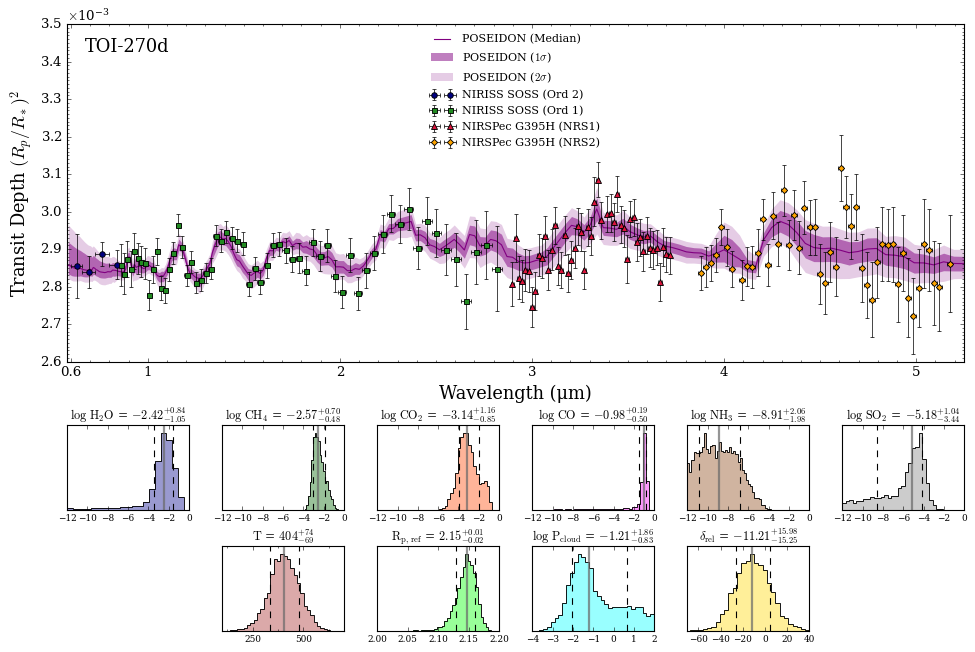

<Figure size 853.36x480 with 0 Axes>

<Figure size 600x800 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt


fig_combined = plt.figure(constrained_layout=True, figsize=(12,8.0))
                          
axd = fig_combined.subplot_mosaic(
    """
    AAAAAA
    AAAAAA
    AAAAAA
    AAAAAA
    abcdef
    .ghij.
    """
)

ax_spectrum = axd["A"]
axes_histograms = [axd["a"], axd["b"], axd["c"], axd["d"], axd["e"], 
                   axd["f"], axd["g"], axd["h"], axd["i"], axd["j"]]

_ = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                                    spectra_high1, spectra_high2, planet_name,
                                    data, R_to_bin = 100, show_ymodel = False,
                                    plt_label = None,
                                    colour_list = ['purple'],
                                    data_colour_list = ['navy', 'forestgreen',
                                                        'crimson', 'orange'],
                                    spectra_labels = ['POSEIDON'],
                                    data_labels = ['NIRISS SOSS (Ord 2)', 'NIRISS SOSS (Ord 1)',
                                                    'NIRSpec G395H (NRS1)', 'NIRSpec G395H (NRS2)'],
                                    data_marker_list = ['o', 's',
                                                        '^', 'D'],
                                    data_marker_size_list = [5, 4.5,
                                                             6, 4],
                                    figure_shape = 'wide', wl_axis = 'linear',
                                    legend_location = 'upper center',
                                    wl_min = 0.58, wl_max = 5.25,
                                    y_min = 2.6e-3, y_max = 3.5e-3,
                                    # show_data_bin_width = False,
                                    # show_data_cap = False,
                                    # data_alpha = 0.6,
                                    save_fig = False,
                                    # data_edge_width = 1.2,
                                    ax = ax_spectrum,
                                 #   text_annotations = ['Aerosols?', 'CrH?', 'H$_2$O', 
                                 #                       'H$_2$O', 'Cloud', 'H$_2$O', 'H$_2$O'],
                                 #   annotation_pos = [(0.63, 5.36e-3), (0.8, 5.45e-3), (1.08, 5.20e-3), 
                                 #                     (1.35, 5.38e-3), (1.57, 5.12e-3), (1.84, 5.30e-3), (2.5, 5.52e-3)],
                                    )

models = [model]

_ = plot_histograms(planet_name, models, plot_parameters = ['log_H2O', 'log_CH4', 'log_CO2', 'log_CO', 'log_NH3', 
                                                            'log_SO2', 'T', 'R_p_ref', 'log_P_cloud', 'delta_rel'],
                    parameter_colour_list = ['darkblue', 'darkgreen', 'orangered', 'magenta', 'saddlebrown', 'grey', 'brown', 'lime', 'cyan', 'gold'],
                    span = ((-12, 0), (-12, 0), (-12, 0), (-12, 0), (-12, 0), 
                            (-12, 0), (100, 700), (2, 2.2), (-4, 2), (-70, 40)),
                    N_bins = [20, 20, 30, 40, 40, 
                              30, 30, 30, 30, 30],
                    retrieval_colour_list = ['purple', 'orangered'],
                    axes = axes_histograms, save_fig = False,
                    retrieval_codes = ['POSEIDON', 'POSEIDON'],
                    )

fig_combined.savefig('./POSEIDON_output/TOI-270d/plots/Retrieval_Combined.pdf', bbox_inches='tight', dpi=800)